# ImfitDummy

Minimal image fitting program for testing things

## Function definitions

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from lib.imageRead import readImage
from lib.imageProcess import calcOD as calcOD_class

import sys, os

from PyQt5 import QtWidgets, QtCore
import ctypes

from lib.imageRead import *
from lib.imageProcess import *
from lib.imfitDefaults import *
from lib.gui_helpers import *

import numpy as np

from pymongo import MongoClient, errors
from bson.json_util import loads, dumps

from datetime import datetime

## Sample script

In [52]:
mode = "Side iXon"
path = 'K:/data/2025/05/20250526/Andor/'
print(path)

K:/data/2025/05/20250526/Andor/


In [57]:
# fig, ax = plt.subplots(1, 6, figsize=(15, 5))
firstFile = True


x =[116, 117, 118, 119, 120, 121, 122, 124, 125] # list of files to read
# x =[116] # list of files to read
# path = IMFIT_MODES[mode]["Default Path"]
firstFile = True
if x is not None:
    for k in x:
        # FOR NOW IMPLEMENTING ONLY FOR iXon Side
        print((path + 'ixon_{}.npz').format(k))
        currentFile = readImage(mode,  (path + 'ixon_{}.npz').format(k))
        if currentFile is None:
            print('this is a test anyway')
        if firstFile:
            avg_frame_dict = currentFile.frames
            firstFile = False
        else:
            frames, metadata = currentFile.getData()
            species_list = list(currentFile.frames.keys())
            for idx, species in enumerate(species_list):
                frame_list = list(currentFile.frames[species].keys())
                for idy, frame_name in enumerate(frame_list):
                    cntr = idx * len(frame_list) + idy
                    species_frame = currentFile.frames[species][frame_name]
                    avg_frame_dict[species][frame_name] += species_frame

            # imageAdd, metadata = currentFile.getData()#.img
            # imageMean += imageAdd / float(len(x))

for idx, species in enumerate(species_list):
    frame_list = list(currentFile.frames[species].keys())
    for idy, frame_name in enumerate(frame_list):
        cntr = idx * len(frame_list) + idy
        #Actually put the average image in the current image dict
        currentFile.frames[species][frame_name] = avg_frame_dict[species][frame_name] / float(len(x))
        # ax[cntr].imshow(currentFile.frames[species][frame_name])


K:/data/2025/05/20250526/Andor/ixon_116.npz
K:/data/2025/05/20250526/Andor/ixon_117.npz
K:/data/2025/05/20250526/Andor/ixon_118.npz
K:/data/2025/05/20250526/Andor/ixon_119.npz
K:/data/2025/05/20250526/Andor/ixon_120.npz
K:/data/2025/05/20250526/Andor/ixon_121.npz
K:/data/2025/05/20250526/Andor/ixon_122.npz
K:/data/2025/05/20250526/Andor/ixon_124.npz
K:/data/2025/05/20250526/Andor/ixon_125.npz


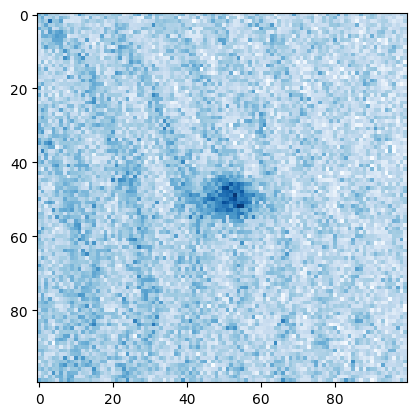

In [58]:
def calc_OD(image, species, region):
    return calcOD_class(image, species, mode, region).ODCorrected

OD = calc_OD(currentFile, "K", [87, 244, 100, 100])
# print(OD)
plt.figure()
plt.imshow(OD, cmap = 'Blues', clim = [-0.04, .01])